# Three datasets

- course materials = **training dataset**
    - amount of data: 60-80%
    - how often is used: always
- practice exam = **validation set**
    - amount of data: 10-20%
    - how often is used: often but not always
- final exam = **test set**
    - amount of data: 10-20%
    - how often is used: always

In [1]:
import torch

weight = 0.7
bias = 0.3
X = torch.arange(0, 1, 0.02).unsqueeze(dim=1)
y = weight * X + bias

X[:10], y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

In [2]:
train_split = int(0.8 * len(X))
train_split

40

In [3]:
X_train, y_train = X[:train_split], y[:train_split]
X_test, y_test = X[train_split:], y[train_split:]

In [4]:
len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

In [5]:
from matplotlib import pyplot as plt


def plot_predictions(train_data=X_train,
                     train_labels=y_train,
                     test_data=X_test,
                     test_labels=y_test,
                     predictions=None):
    """
    Plots training data, test data and compares predictions.
    """
    # plot training data in blue
    plt.scatter(train_data, train_labels, s=4, color='b', label='Training data')
    # plot training data in green
    plt.scatter(test_data, test_labels, s=4, color='y', label='Testing data')
    # are there predictions?
    if predictions is not None:
        plt.scatter(test_data, predictions, s=4, color='r', label='Predictions')

    # show the legend
    plt.legend(prop={'size': 14})

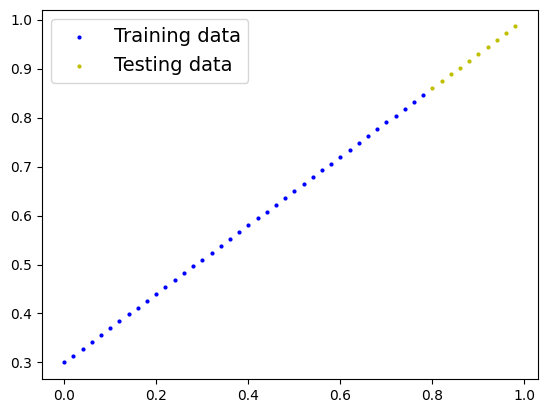

In [6]:
plot_predictions()

# Build a model

We create a model which predicts linear regression (in a forward way), what we implemented before.

In [7]:
# create linear regression model class
import torch.nn as nn

class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))
        self.bias = nn.Parameter(torch.randn(1, requires_grad=True, dtype=torch.float32))

    # forward method to define the computation in a model, x=input data
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # we implement the linear regression formula here
        return self.weight * x + self.bias

Now we created a model class with parameters.

When we created our data we knew what the parameters weight and bias were.

The whole goal of the model is to start with random numbers and look the data, and update those random numbers to represent the testing data pattern.

It only modifies the parameters (weight, bias) and tries to find out the pattern (from x).

Which is:
(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000], ...

Gradient descent is used to find out the parameters.

What our model does:

- start with random values (weight, bias)
- look at training data (x)
- adjust the random values to better represent (or get closer) to ideal values (weight, bias)

How does it do?

- gradient descent (requires_grad=True)
- backpropagation

When we run computation, pytorch keep tracks of gradients of our parameters.
And it's going to update them through a combination of gradient descent and backpropagation.

# Model building essentials

- torch.nn - contains all the building blocks for computational graphs
- torch.nn.Parameter - what parameters should our model to learn
- torch.nn.Module - base class for all NN modules
- torch.optim - this where the optimizers in PyTorch live, they will help with gradient descent. (optimizing parameters)
- def forward() - all nn.Module subclasses require you to overwrite this method